<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/LSTM_Basic_00_AutoregressionLinearModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.test.is_built_with_cuda())
# Using the recommended method to check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} device(s) found.")
else:
    print("No GPU devices found.")

2.19.0
True
No GPU devices found.


In [2]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

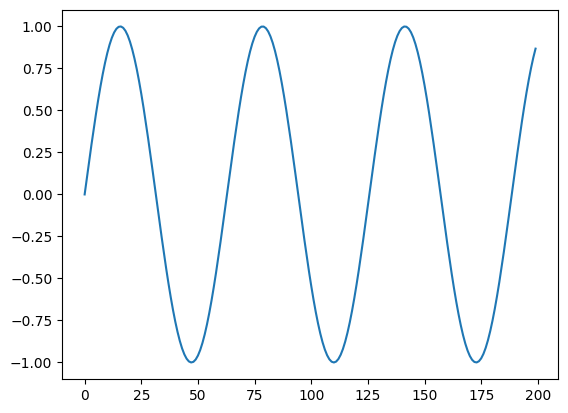

In [3]:
# make the original data
series = np.sin(0.1*np.arange(200)) #+ np.random.randn(200)*0.1

# plot it
plt.plot(series)
plt.show()

In [8]:
series

array([ 0.        ,  0.09983342,  0.19866933,  0.29552021,  0.38941834,
        0.47942554,  0.56464247,  0.64421769,  0.71735609,  0.78332691,
        0.84147098,  0.89120736,  0.93203909,  0.96355819,  0.98544973,
        0.99749499,  0.9995736 ,  0.99166481,  0.97384763,  0.94630009,
        0.90929743,  0.86320937,  0.8084964 ,  0.74570521,  0.67546318,
        0.59847214,  0.51550137,  0.42737988,  0.33498815,  0.23924933,
        0.14112001,  0.04158066, -0.05837414, -0.15774569, -0.2555411 ,
       -0.35078323, -0.44252044, -0.52983614, -0.61185789, -0.68776616,
       -0.7568025 , -0.81827711, -0.87157577, -0.91616594, -0.95160207,
       -0.97753012, -0.993691  , -0.99992326, -0.99616461, -0.98245261,
       -0.95892427, -0.92581468, -0.88345466, -0.83226744, -0.77276449,
       -0.70554033, -0.63126664, -0.55068554, -0.46460218, -0.37387666,
       -0.2794155 , -0.1821625 , -0.0830894 ,  0.0168139 ,  0.1165492 ,
        0.21511999,  0.31154136,  0.40484992,  0.49411335,  0.57

#Budowa Dataset do predykcji - moving window

In [9]:
### build the dataset  # budujemy zbiór uczący z szeregu czasowego: okno -> następna wartość
# let's see if we can use T past values to predict the next value  # cel: T próbek wstecz ma przewidzieć 1 próbkę naprzód

T = 10  # 10 previous timestamps to predict the next value  # długość okna: ile poprzednich punktów pokazujemy modelowi
X = []  # list of X values  # lista wejść: każde X to wektor długości T
Y = []  # list of Y values  # lista etykiet: każda Y to pojedyncza wartość po oknie

for t in range(len(series) - T):  # iterujemy po wszystkich możliwych oknach, które mieszczą się w serii
  x = series[t:t+T]  # wycinamy okno: [t, ..., t+T-1] (T punktów)
  X.append(x)  # dodajemy okno do zbioru wejść
  y = series[t+T]  # etykieta: punkt zaraz po oknie (1-step ahead)
  Y.append(y)  # dodajemy etykietę do zbioru wyjść

X = np.array(X).reshape(-1, T)  # konwersja do numpy; tu X ma kształt (N,T) bo bez wymiaru "features"
Y = np.array(Y)  # konwersja etykiet do numpy; zwykle shape (N,)
N = len(X)  # liczba próbek (okien) w zbiorze
print("X.shape", X.shape, "Y.shape", Y.shape)  # kontrola wymiarów: X=(N,T), Y=(N,)


X.shape (190, 10) Y.shape (190,)


In [10]:
X


array([[ 0.        ,  0.09983342,  0.19866933, ...,  0.64421769,
         0.71735609,  0.78332691],
       [ 0.09983342,  0.19866933,  0.29552021, ...,  0.71735609,
         0.78332691,  0.84147098],
       [ 0.19866933,  0.29552021,  0.38941834, ...,  0.78332691,
         0.84147098,  0.89120736],
       ...,
       [-0.14899903, -0.04953564,  0.05042269, ...,  0.52306577,
         0.60553987,  0.68196362],
       [-0.04953564,  0.05042269,  0.14987721, ...,  0.60553987,
         0.68196362,  0.75157342],
       [ 0.05042269,  0.14987721,  0.24783421, ...,  0.68196362,
         0.75157342,  0.81367374]])

In [11]:
Y #to jest macierz jednowymiarowa generowanego sinusa, przesunięta o T, żeby pasowało okno

array([ 0.84147098,  0.89120736,  0.93203909,  0.96355819,  0.98544973,
        0.99749499,  0.9995736 ,  0.99166481,  0.97384763,  0.94630009,
        0.90929743,  0.86320937,  0.8084964 ,  0.74570521,  0.67546318,
        0.59847214,  0.51550137,  0.42737988,  0.33498815,  0.23924933,
        0.14112001,  0.04158066, -0.05837414, -0.15774569, -0.2555411 ,
       -0.35078323, -0.44252044, -0.52983614, -0.61185789, -0.68776616,
       -0.7568025 , -0.81827711, -0.87157577, -0.91616594, -0.95160207,
       -0.97753012, -0.993691  , -0.99992326, -0.99616461, -0.98245261,
       -0.95892427, -0.92581468, -0.88345466, -0.83226744, -0.77276449,
       -0.70554033, -0.63126664, -0.55068554, -0.46460218, -0.37387666,
       -0.2794155 , -0.1821625 , -0.0830894 ,  0.0168139 ,  0.1165492 ,
        0.21511999,  0.31154136,  0.40484992,  0.49411335,  0.57843976,
        0.6569866 ,  0.72896904,  0.79366786,  0.85043662,  0.8987081 ,
        0.93799998,  0.96791967,  0.98816823,  0.99854335,  0.99

In [12]:
### try autoregressive linear model  # liniowy baseline: T przeszłych próbek -> 1 przyszła (bez pamięci RNN, czysta regresja)
i = Input(shape=(T,))  # wejście: wektor długości T (T cech); tu nie ma osi czasu, tylko "feature vector"
x = Dense(1)(i)  # warstwa liniowa: y = w^T x + b (regresja); Dense domyślnie ma aktywację liniową
model = Model(i, x)  # składamy model: Input -> Dense

model.compile(  # konfigurujemy uczenie: jaka funkcja straty i jaki optymalizator
  loss='mse',  # MSE: średni błąd kwadratowy; standard dla regresji
  optimizer=Adam(learning_rate=0.1),  # Adam z LR=0.1 (agresywnie duży krok; może szybciej uczyć, ale łatwo przeskoczyć optimum)
)

# train the RNN  # UWAGA: to NIE jest RNN; to liniowy model Dense (opis w komentarzu jest mylący)
r = model.fit(  # start treningu; zwróci historię loss/val_loss do r
  X[:-N//2], Y[:-N//2],  # train: pierwsza połowa danych (zachowanie porządku czasu, brak leakage)
  epochs=80,  # liczba epok; bez EarlyStopping może przeuczać
  validation_data=(X[-N//2:], Y[-N//2:]),  # walidacja: druga połowa (późniejszy czas)
)  # domknięcie fit (u Ciebie wklejka urwana, tu powinien być nawias)


Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0378 - val_loss: 0.0494
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0466 - val_loss: 0.0611
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0685 - val_loss: 0.0266
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0215 - val_loss: 0.0030
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0093 - val_loss: 0.0201
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0094 - val_loss: 0.0107
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0100 - val_loss: 0.0048
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0056 - val_loss: 0.0028
Epoch 9/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 10/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 11/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 12/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0021 - val_loss: 0.0012


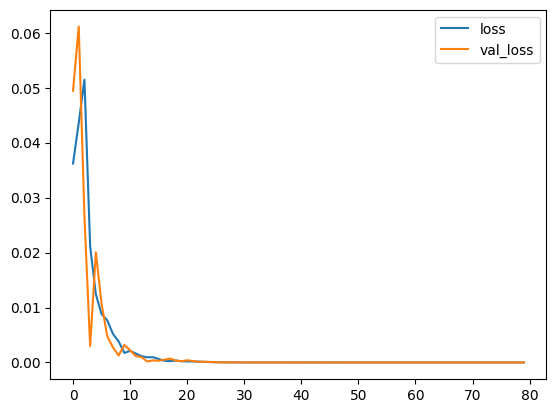

In [13]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

#Incorrect Method forecast

In [18]:
# "Wrong" forecast using true targets

validation_target = Y[-N//2:] #assign validation series, second half of Y (druga część ciągu)
validation_predictions = [] #empty list for validation prediction

# index of first validation input
i = -N//2 #liczba okien w zbiorze -> 190 bo 190 okien po 10 wartości bo T, czyli i zaczynamy od 190/2 - floor z N/2
#set index at first index of validation set
print(i)

while len(validation_predictions) < len(validation_target):
  p = model.predict(X[i].reshape(1, -1))[0,0] # 1x1 array -> scalar
  i += 1

  # update the predictions list
  validation_predictions.append(p)

-95
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━

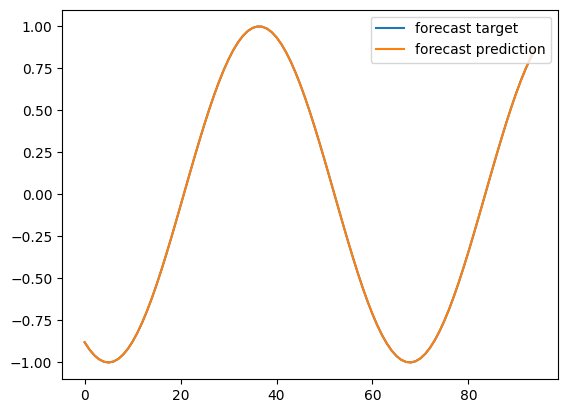

In [19]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

#Forecast correct way

first validation input line is different.

Before, we just had an index i,

and we used i to index X, the input data.

But the problem was

we shouldn't have been using the true input data

to predict future values of the time series.

Instead, we'll set the variable last_x

to be the first input vector.

From here on out, we will no longer take any new values

from the actual dataset.

So next, we enter the loop.

In [20]:
# Forecast future values (use only self-predictions for making future predictions)

validation_target = Y[-N//2:]
validation_predictions = []

# first validation input
last_x = X[-N//2] # 1-D array of length T

while len(validation_predictions) < len(validation_target):
  p = model.predict(last_x.reshape(1, -1))[0,0] # 1x1 array -> scalar

  # update the predictions list
  validation_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

podsumowanie

oba kody używają tych samych danych walidacyjnych do OCENY (validation_target = Y[-N//2:]). Różnica jest w tym, co podajesz na wejście modelu podczas prognozy. Pierwszy kod NIE robi „forecast przyszłości” – robi tylko 1-punktową predykcję na oknach walidacyjnych (z prawdziwych danych). Drugi kod robi prawdziwy forecast wielokrokowy (free-running), bo karmi model jego własnymi predykcjami.

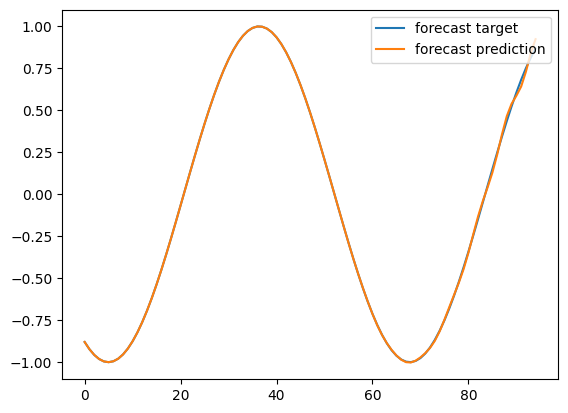

In [21]:
plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()